#TAREA COLABORATIVA
Version: 1.0

Integrantes:
*   Alcantara Rivera Jose Alexander
*   Alfaro Gutierrez Dermy Edsel
*   Ancalle Gonzales Fabio Steve








##CARGA DE DATOS
Creación de dataframes

In [67]:
#IMPORTACIÓN DE LIBRERIAS Y CREDENCIALES DE GOOGLE NECESARIAS
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

import pandas as pd

In [68]:
#ID DEL ARCHIVO GOOGLE HOJA DE CALCULO
spreadsheet_id = '1ITosjKJPVbGxSci9nMA8YcLt1T8B9F0qd1xj6wNrNco'
#CARGAMOS EL ARCHIVO DE GOOGLE SHEETS(DB)
spreadsheet = gc.open_by_key(spreadsheet_id)

#CREAMOS EL DATAFRAME CON LA INFORMACIÓN DE VENTAS
worksheet_ventas = spreadsheet.get_worksheet(0)
rows = worksheet_ventas.get_all_values()
df_ventas = pd.DataFrame.from_records(rows[1:], columns=rows[0])
df_ventas.head()

,ID,Fecha,Canal,Cliente,Ubicación,Segmento,ID_Vehículo,Precio Venta sin IGV,Vendedor
0,1,7/7/2017,Publicidad en la radio,ABAB RIVERA EMILIA,"San Miguel, Lima, Lima",Persona,137,28281,Sebastián Sánchez
1,2,7/6/2017,Publicidad en Google,ABAD ARRUNATEGUI MITZI FIORELLA,"Ate,Lima,Lima",Persona,59,38379,Nicolás Mangia
2,3,7/5/2017,Publicidad en Google,ABAD AYALA CECILIA LORENA,"Ate,Lima,Lima",Persona,21,18198,Nicolás Mangia
3,4,7/4/2017,Publicidad en Google,ABAD BELTRAN CARMELA EVA,"Ate,Lima,Lima",Persona,61,31536,Nicolás Mangia
4,5,7/3/2017,Publicidad en Google,ABAD CAMARENA LUIS ANTONIO,"Ate,Lima,Lima",Persona,111,18274,Nicolás Mangia


In [69]:
#CREAMOS EL DATAFRAME CON LA INFORMACIÓN DE VEHICULOS
worksheet_vehiculos = spreadsheet.get_worksheet(1)
rows = worksheet_vehiculos.get_all_values()
df_vehiculos = pd.DataFrame.from_records(rows[1:], columns=rows[0])
df_vehiculos.head()

,ID_Vehiculo,MARCA,MODELO,TIPO_VEHÍCULO,AÑO
0,1,HONDA,ACCORD,AUTO,2014
1,2,HONDA,CIVIC,AUTO,2014
2,3,HONDA,ODISSEY,AUTO,2013
3,4,HONDA,CRV,AUTO,2014
4,5,HONDA,PILOT,AUTO,2013


In [70]:
#DESCRIPCIÓN DEL DATASET VENTAS
df_ventas.info()
df_ventas.describe()
#verificamos que es un dataset de 14202 filas y a ninguna columna le falta valores

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14202 entries, 0 to 14201
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    14202 non-null  object
 1   Fecha                 14202 non-null  object
 2   Canal                 14202 non-null  object
 3   Cliente               14202 non-null  object
 4   Ubicación             14202 non-null  object
 5   Segmento              14202 non-null  object
 6   ID_Vehículo           14202 non-null  object
 7   Precio Venta sin IGV  14202 non-null  object
 8   Vendedor              14202 non-null  object
dtypes: object(9)
memory usage: 998.7+ KB


,ID,Fecha,Canal,Cliente,Ubicación,Segmento,ID_Vehículo,Precio Venta sin IGV,Vendedor
count,14202,14202,14202,14202,14202,14202,14202,14202,14202
unique,14202,928,9,14140,4,2,179,10420,12
top,14202,5/20/2015,CRM,DIONICIO POLONIO KELLY RAQUEL,"Surco,Lima,Lima",Persona,41,37609,Norma Domínguez
freq,1,54,1728,2,8291,12356,103,5,1263


In [71]:
df_ventas.dtypes

,0
ID,object
Fecha,object
Canal,object
Cliente,object
Ubicación,object
Segmento,object
ID_Vehículo,object
Precio Venta sin IGV,object
Vendedor,object


In [72]:
#DESCRIPCIÓN DEL DATASET VEHICULOS
df_vehiculos.info()
df_vehiculos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID_Vehiculo    180 non-null    object
 1   MARCA          180 non-null    object
 2   MODELO         180 non-null    object
 3   TIPO_VEHÍCULO  180 non-null    object
 4   AÑO            180 non-null    object
dtypes: object(5)
memory usage: 7.2+ KB


,ID_Vehiculo,MARCA,MODELO,TIPO_VEHÍCULO,AÑO
count,180,180,180,180,180
unique,180,6,70,4,7
top,1,TOYOTA,GENESIS,AUTO,2016
freq,1,53,6,103,33


##GENERACIÓN DE INFORMACIÓN NECESARIA

In [73]:
#CALCULO DEL COSTO ORIGINAL DEL VEHÍCULO
df_ventas['Precio Venta sin IGV'] = pd.to_numeric(df_ventas['Precio Venta sin IGV'], errors='coerce')
df_ventas['Costo Vehiculo'] = 0.6 * df_ventas['Precio Venta sin IGV']
#CALCULO DEL PRECIO DE VENTA REAL (MÁS IGV)
df_ventas['Precio Venta Real'] = df_ventas['Precio Venta sin IGV'] + 0.18 * df_ventas['Precio Venta sin IGV']
#VISUALIZAMOS LOS 10 PRIMEROS VALORES
df_ventas.head(10)

,ID,Fecha,Canal,Cliente,Ubicación,Segmento,ID_Vehículo,Precio Venta sin IGV,Vendedor,Costo Vehiculo,Precio Venta Real
0,1,7/7/2017,Publicidad en la radio,ABAB RIVERA EMILIA,"San Miguel, Lima, Lima",Persona,137,28281,Sebastián Sánchez,16968.6,33371.58
1,2,7/6/2017,Publicidad en Google,ABAD ARRUNATEGUI MITZI FIORELLA,"Ate,Lima,Lima",Persona,59,38379,Nicolás Mangia,23027.4,45287.22
2,3,7/5/2017,Publicidad en Google,ABAD AYALA CECILIA LORENA,"Ate,Lima,Lima",Persona,21,18198,Nicolás Mangia,10918.8,21473.64
3,4,7/4/2017,Publicidad en Google,ABAD BELTRAN CARMELA EVA,"Ate,Lima,Lima",Persona,61,31536,Nicolás Mangia,18921.6,37212.48
4,5,7/3/2017,Publicidad en Google,ABAD CAMARENA LUIS ANTONIO,"Ate,Lima,Lima",Persona,111,18274,Nicolás Mangia,10964.4,21563.32
5,6,7/2/2017,Newsletter,ABAD CHUQUIHUANGA ROMELIA,"La Molina,Lima, Lima",Persona,37,35689,Gastón García,21413.4,42113.02
6,7,7/1/2017,Newsletter,ABAD CRUZ GALVANY,"La Molina,Lima, Lima",Persona,32,34097,Gastón García,20458.2,40234.46
7,8,6/30/2017,Newsletter,ABAD DE FIESTAS MARIA CRISTINA,"La Molina,Lima, Lima",Persona,156,36052,Gastón García,21631.2,42541.36
8,9,6/29/2017,Newsletter,ABAD ECHEGARAY JUAN RICARDO,"La Molina,Lima, Lima",Persona,45,29823,Gastón García,17893.8,35191.14
9,10,6/28/2017,Email en frío,ABAD JARAMILLO DADEPERE MARIA MAGDALENA,"San Miguel, Lima, Lima",Empresa,97,22387,Sebastián Sánchez,13432.2,26416.66


In [74]:
#OBTENCIÓN DE LA SEDE
df_ventas[['Distrito', 'Provincia', 'Departamento']] = df_ventas['Ubicación'].str.split(',', expand=True)
df_ventas=df_ventas.rename(columns={'Distrito': 'Sede'}) #Renombre de la columna a sede
#RELIZAMOS UN JOIN DE LOS DF VENTAS Y VEHICULOS
df_ventas = pd.merge(df_ventas, df_vehiculos,left_on='ID_Vehículo',right_on='ID_Vehiculo', how='inner')
df_ventas.head()

,ID,Fecha,Canal,Cliente,Ubicación,Segmento,ID_Vehículo,Precio Venta sin IGV,Vendedor,Costo Vehiculo,Precio Venta Real,Sede,Provincia,Departamento,ID_Vehiculo,MARCA,MODELO,TIPO_VEHÍCULO,AÑO
0,1,7/7/2017,Publicidad en la radio,ABAB RIVERA EMILIA,"San Miguel, Lima, Lima",Persona,137,28281,Sebastián Sánchez,16968.6,33371.58,San Miguel,Lima,Lima,137,SUZUKI,XL7,AUTO,2014
1,2,7/6/2017,Publicidad en Google,ABAD ARRUNATEGUI MITZI FIORELLA,"Ate,Lima,Lima",Persona,59,38379,Nicolás Mangia,23027.4,45287.22,Ate,Lima,Lima,59,TOYOTA,AVENSIS,CAMIONETA,2013
2,3,7/5/2017,Publicidad en Google,ABAD AYALA CECILIA LORENA,"Ate,Lima,Lima",Persona,21,18198,Nicolás Mangia,10918.8,21473.64,Ate,Lima,Lima,21,MAZDA,CX9,CAMIONETA,2014
3,4,7/4/2017,Publicidad en Google,ABAD BELTRAN CARMELA EVA,"Ate,Lima,Lima",Persona,61,31536,Nicolás Mangia,18921.6,37212.48,Ate,Lima,Lima,61,TOYOTA,HILUX PICK UP,AUTO,2012
4,5,7/3/2017,Publicidad en Google,ABAD CAMARENA LUIS ANTONIO,"Ate,Lima,Lima",Persona,111,18274,Nicolás Mangia,10964.4,21563.32,Ate,Lima,Lima,111,SUZUKI,SX4,AUTO,2012


##NORMALIZACIÓN Y ETIQUETADO DE DATOS
A fin de realizar la normalización y etiquetado de datos para un posterior procesamiento, creamos otro dataframe

In [75]:
#ELIMINACIÓN DE COLUMNAS QUE SE CONSIDERAN NO NECESARIAS PARA EL ANÁLISIS
df= df_ventas.drop(columns=['Ubicación', 'ID_Vehículo','ID_Vehiculo','Provincia','Departamento','Cliente','MARCA','MODELO','Vendedor'])
df.set_index('ID', inplace=True)
df.head()

,Fecha,Canal,Segmento,Precio Venta sin IGV,Costo Vehiculo,Precio Venta Real,Sede,TIPO_VEHÍCULO,AÑO
ID,,,,,,,,,
1,7/7/2017,Publicidad en la radio,Persona,28281,16968.6,33371.58,San Miguel,AUTO,2014
2,7/6/2017,Publicidad en Google,Persona,38379,23027.4,45287.22,Ate,CAMIONETA,2013
3,7/5/2017,Publicidad en Google,Persona,18198,10918.8,21473.64,Ate,CAMIONETA,2014
4,7/4/2017,Publicidad en Google,Persona,31536,18921.6,37212.48,Ate,AUTO,2012
5,7/3/2017,Publicidad en Google,Persona,18274,10964.4,21563.32,Ate,AUTO,2012


In [76]:
#NORMALIZACIÓN DE VALORES DE VENTA Y COSTO ()
from sklearn.preprocessing import MinMaxScaler,LabelEncoder

scaler = MinMaxScaler()
df['Precio Venta sin IGV'] = scaler.fit_transform(df[['Precio Venta sin IGV']])
df['Costo Vehiculo'] = scaler.fit_transform(df[['Costo Vehiculo']])
df['Precio Venta Real'] = scaler.fit_transform(df[['Precio Venta Real']])
df.head()

,Fecha,Canal,Segmento,Precio Venta sin IGV,Costo Vehiculo,Precio Venta Real,Sede,TIPO_VEHÍCULO,AÑO
ID,,,,,,,,,
1,7/7/2017,Publicidad en la radio,Persona,0.467339,0.467339,0.467339,San Miguel,AUTO,2014
2,7/6/2017,Publicidad en Google,Persona,0.926360,0.926360,0.926360,Ate,CAMIONETA,2013
3,7/5/2017,Publicidad en Google,Persona,0.009000,0.009000,0.009000,Ate,CAMIONETA,2014
4,7/4/2017,Publicidad en Google,Persona,0.615301,0.615301,0.615301,Ate,AUTO,2012
5,7/3/2017,Publicidad en Google,Persona,0.012455,0.012455,0.012455,Ate,AUTO,2012


In [77]:
#TRANSFORMACIÓN LINEAL PARA EL AÑO DE FRABRICACIÓN DEL VEHÍCULO
le = LabelEncoder()
df['AÑO'] = le.fit_transform(df['AÑO'])
df=df.rename(columns={'AÑO': 'ano_fabricacion'}) #Renombre de la columna
df.head()

,Fecha,Canal,Segmento,Precio Venta sin IGV,Costo Vehiculo,Precio Venta Real,Sede,TIPO_VEHÍCULO,ano_fabricacion
ID,,,,,,,,,
1,7/7/2017,Publicidad en la radio,Persona,0.467339,0.467339,0.467339,San Miguel,AUTO,2
2,7/6/2017,Publicidad en Google,Persona,0.926360,0.926360,0.926360,Ate,CAMIONETA,1
3,7/5/2017,Publicidad en Google,Persona,0.009000,0.009000,0.009000,Ate,CAMIONETA,2
4,7/4/2017,Publicidad en Google,Persona,0.615301,0.615301,0.615301,Ate,AUTO,0
5,7/3/2017,Publicidad en Google,Persona,0.012455,0.012455,0.012455,Ate,AUTO,0


In [78]:
#ONE HOT ENCODING SEGUN TIPO DE VEHICULO, SEGMENTO Y SEDE
df_encoded_tv = pd.get_dummies(df.TIPO_VEHÍCULO, dtype=int)
df_encoded_seg = pd.get_dummies(df.Segmento, dtype=int)
df_encoded_sede = pd.get_dummies(df.Sede, dtype=int)
df=pd.concat([df,df_encoded_tv],axis=1)
df=pd.concat([df,df_encoded_seg],axis=1)
df=pd.concat([df,df_encoded_sede],axis=1)
df= df.drop(columns=['Sede','Segmento', 'TIPO_VEHÍCULO'])
df.head()


,Fecha,Canal,Precio Venta sin IGV,Costo Vehiculo,Precio Venta Real,ano_fabricacion,AUTO,AUTOBUS,CAMIONETA,CAMIÓN,Empresa,Persona,Ate,La Molina,San Miguel,Surco
ID,,,,,,,,,,,,,,,,
1,7/7/2017,Publicidad en la radio,0.467339,0.467339,0.467339,2,1,0,0,0,0,1,0,0,1,0
2,7/6/2017,Publicidad en Google,0.926360,0.926360,0.926360,1,0,0,1,0,0,1,1,0,0,0
3,7/5/2017,Publicidad en Google,0.009000,0.009000,0.009000,2,0,0,1,0,0,1,1,0,0,0
4,7/4/2017,Publicidad en Google,0.615301,0.615301,0.615301,0,1,0,0,0,0,1,1,0,0,0
5,7/3/2017,Publicidad en Google,0.012455,0.012455,0.012455,0,1,0,0,0,0,1,1,0,0,0


In [79]:
#LIMPIEZA DE DATOS DE PRECIO
#Debido a que los precios venta sin igv, costo vehiculo y precio venta real son proporcionales. Cuando se realiza la normalización nos da la misma información , por tanto se procede a la eliminación de las columnas
df= df.drop(columns=['Precio Venta sin IGV','Precio Venta Real'])
df=df.rename(columns={'Costo Vehiculo': 'Costo'}) #Renombre de la columna
df.head()

,Fecha,Canal,Costo,ano_fabricacion,AUTO,AUTOBUS,CAMIONETA,CAMIÓN,Empresa,Persona,Ate,La Molina,San Miguel,Surco
ID,,,,,,,,,,,,,,
1,7/7/2017,Publicidad en la radio,0.467339,2,1,0,0,0,0,1,0,0,1,0
2,7/6/2017,Publicidad en Google,0.926360,1,0,0,1,0,0,1,1,0,0,0
3,7/5/2017,Publicidad en Google,0.009000,2,0,0,1,0,0,1,1,0,0,0
4,7/4/2017,Publicidad en Google,0.615301,0,1,0,0,0,0,1,1,0,0,0
5,7/3/2017,Publicidad en Google,0.012455,0,1,0,0,0,0,1,1,0,0,0


In [80]:
#TARGET ENCODING PARA EL CANAL, USANDO COMO BASE LA MEDIA DEL COSTO
mean_map = df.groupby('Canal')['Costo'].mean()
df['canal_encoded'] = df['Canal'].map(mean_map)
df= df.drop(columns=['Canal'])
df.head()

,Fecha,Costo,ano_fabricacion,AUTO,AUTOBUS,CAMIONETA,CAMIÓN,Empresa,Persona,Ate,La Molina,San Miguel,Surco,canal_encoded
ID,,,,,,,,,,,,,,
1,7/7/2017,0.467339,2,1,0,0,0,0,1,0,0,1,0,0.505853
2,7/6/2017,0.926360,1,0,0,1,0,0,1,1,0,0,0,0.501603
3,7/5/2017,0.009000,2,0,0,1,0,0,1,1,0,0,0,0.501603
4,7/4/2017,0.615301,0,1,0,0,0,0,1,1,0,0,0,0.501603
5,7/3/2017,0.012455,0,1,0,0,0,0,1,1,0,0,0,0.501603


In [ ]:
# Convertir la columna a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Extraer Mes y Año en columnas nuevas
df['Mes'] = df['Fecha'].dt.month
df['Año'] = df['Fecha'].dt.year

# Eliminar la columna original
df.drop(columns=['Fecha'], inplace=True)
df.rename(columns={'Costo': 'costo', 'AUTO': 'auto','CAMIÓN':'camion','Año':'ano','MES':'mes','AUTOBUS':'autobus','CAMIONETA':'camioneta','Empresa':'empresa','Persona':'persona'}, inplace=True)
df.head()

,costo,ano_fabricacion,auto,autobus,camioneta,camion,Empresa,Persona,Ate,La Molina,San Miguel,Surco,canal_encoded,Mes,ano
ID,,,,,,,,,,,,,,,
1,0.467339,2,1,0,0,0,0,1,0,0,1,0,0.505853,7,2017
2,0.926360,1,0,0,1,0,0,1,1,0,0,0,0.501603,7,2017
3,0.009000,2,0,0,1,0,0,1,1,0,0,0,0.501603,7,2017
4,0.615301,0,1,0,0,0,0,1,1,0,0,0,0.501603,7,2017
5,0.012455,0,1,0,0,0,0,1,1,0,0,0,0.501603,7,2017


##EXPORTAR DATASET

In [89]:
from google.colab import files
df.to_csv('clear_dataset.csv', index=False)
files.download('clear_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ANALIZANDO DATOS


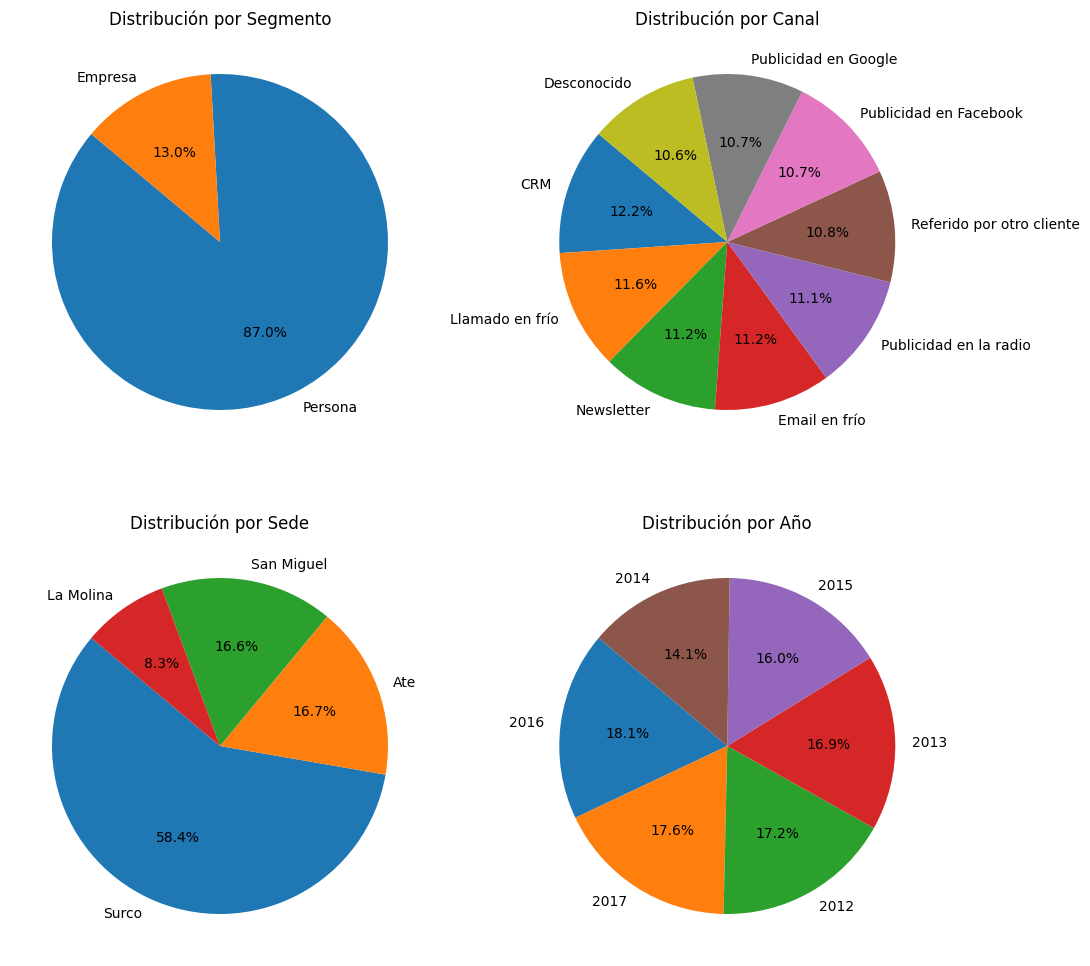

<Figure size 400x400 with 0 Axes>

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(12, 12))


segmentos = df_ventas["Segmento"].value_counts()
canal = df_ventas["Canal"].value_counts()
sede= df_ventas["Sede"].value_counts()
anio=df_ventas["AÑO"].value_counts()

plt.figure(figsize=(4, 4))
axs[0,0].pie(segmentos, labels=segmentos.index, autopct='%1.1f%%', startangle=140)
axs[0,0].set_title('Distribución por Segmento')
axs[0,1].pie(canal, labels=canal.index, autopct='%1.1f%%', startangle=140)
axs[0,1].set_title('Distribución por Canal')
axs[1,0].pie(sede, labels=sede.index, autopct='%1.1f%%', startangle=140)
axs[1,0].set_title('Distribución por Sede')
axs[1,1].pie(anio, labels=anio.index, autopct='%1.1f%%', startangle=140)
axs[1,1].set_title('Distribución por Año')
plt.tight_layout()
plt.show()

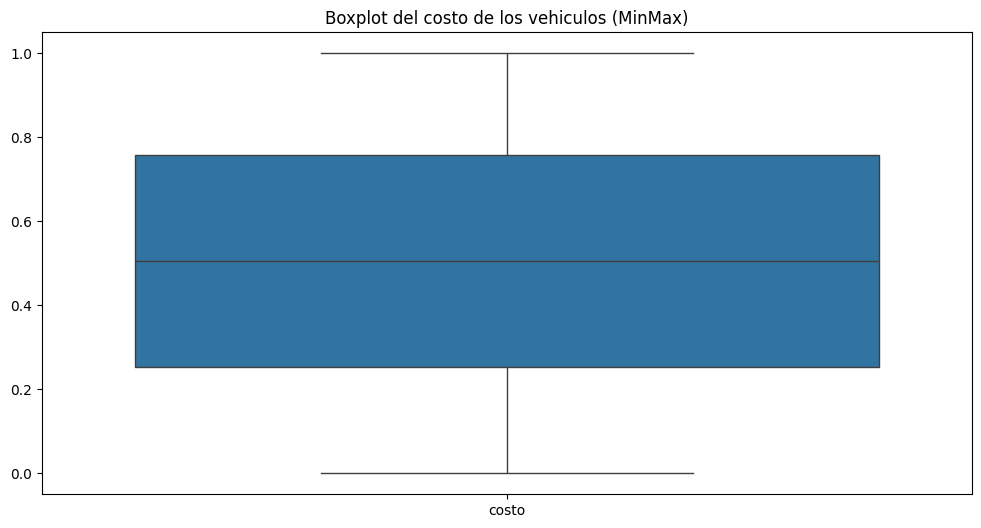

In [84]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['costo']])
plt.title('Boxplot del costo de los vehiculos (MinMax)')
plt.show()
#verificamos que en lo que respecta al costo de los vehículos no existen valores outliers


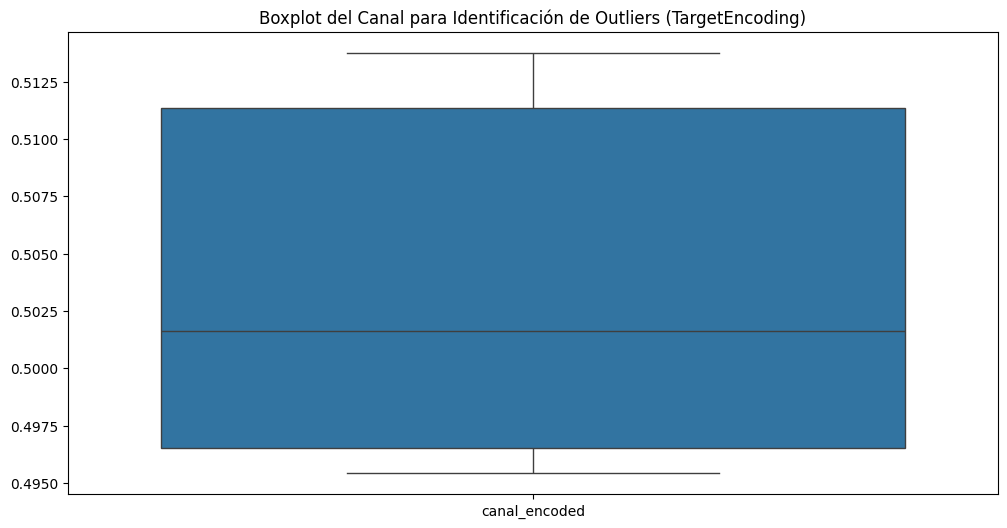

In [85]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['canal_encoded']])
plt.title('Boxplot del Canal para Identificación de Outliers (TargetEncoding)')
plt.show()

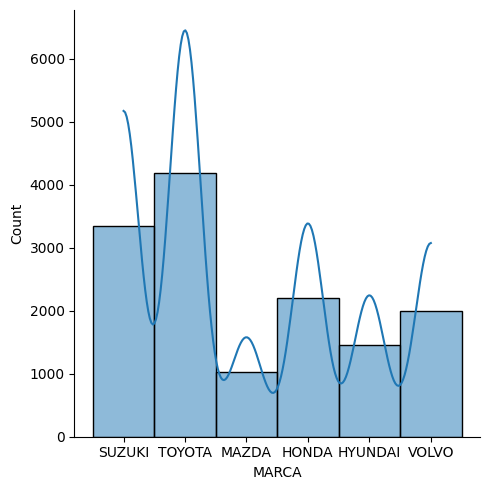

In [86]:
#Gráfico de distribución de las marcas mas demandadas
sns.displot(df_ventas['MARCA'], kde=True)

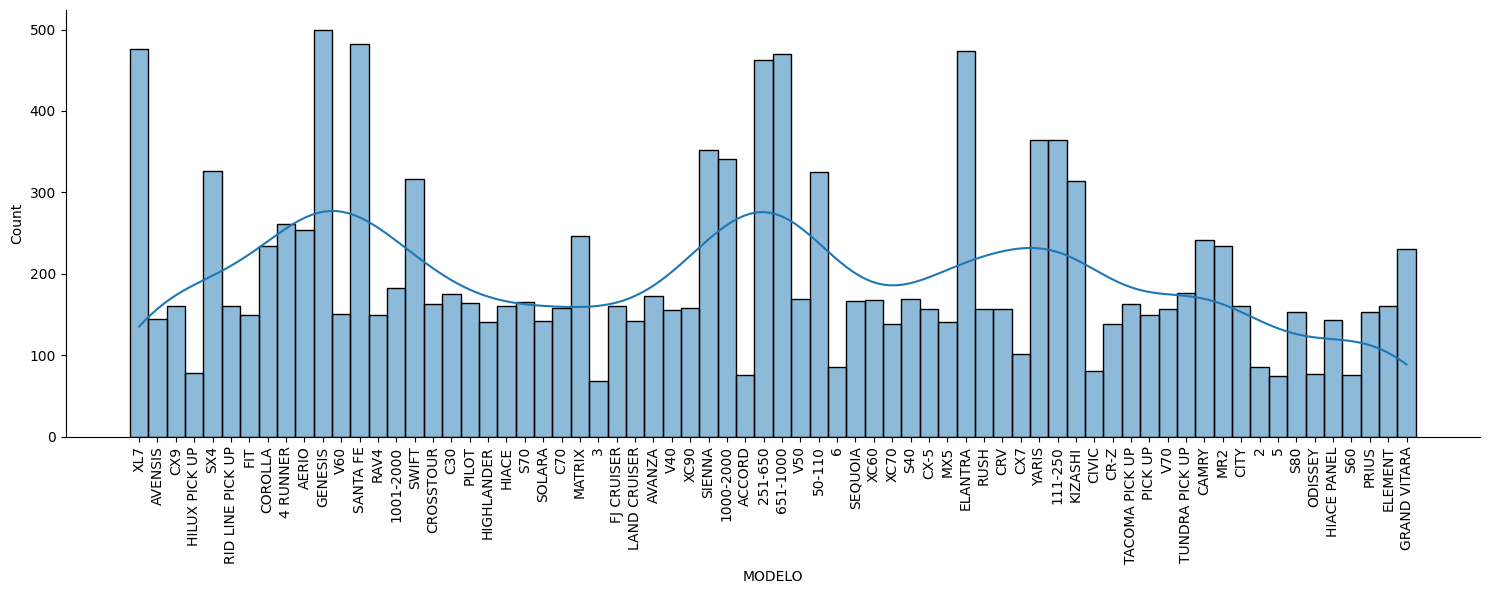

In [87]:
#Gráfico de distribución de los modelos mas demandados
sns.displot(df_ventas['MODELO'], kde=True,height=5, aspect=3)
plt.xticks(rotation=90)
plt.show()

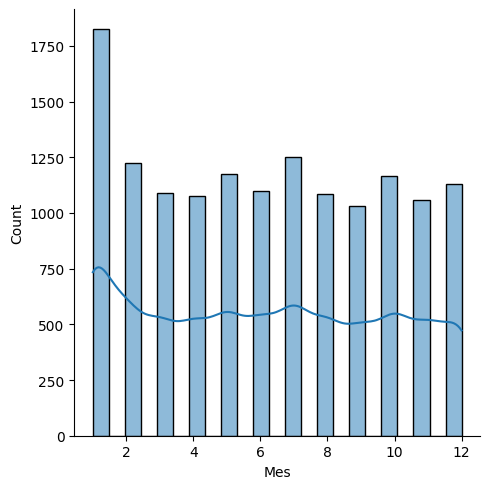

In [88]:
#Gráfico de distribución del mes donde se registra más ventas
sns.displot(df['Mes'], kde=True)
#Como se observa en la gráfica, se registra más ventas en el mes de ENERO